In [6]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from testapp.data import SAMPLE_DATA, SCHEMA

df = pd.DataFrame(SAMPLE_DATA)
print(f"Shape: {df.shape}")
df.head()

Shape: (150, 20)


,id,name,department,role,age,tenure_years,hire_year,education,remote,hours_per_week,projects_completed,training_hours,absences,performance_score,satisfaction_score,salary,bonus_pct,last_review,promoted,churned
0,1,Chris Lewis,Engineering,Mid,33,4.1,2020,Bachelor's,yes,39.1,8,21,11,2.8,4.2,99404.80,6.9,Meets Expectations,False,False
1,2,Julia Anderson,Engineering,Junior,27,4.3,2020,Bachelor's,yes,40.0,9,29,4,3.4,6.1,83233.00,7.2,Meets Expectations,False,False
2,3,Eve Hall,Finance,Senior,39,11.7,2013,Master's,yes,44.1,11,31,6,3.5,8.0,129032.06,9.1,Meets Expectations,False,False
3,4,Uma Wilson,Finance,Mid,32,3.1,2021,Bachelor's,no,38.4,5,0,7,2.3,4.7,97231.92,7.2,Below Expectations,False,False
4,5,Karen Green,Operations,Senior,42,5.4,2019,Bachelor's,no,38.2,0,21,15,2.0,5.8,101991.52,7.8,Meets Expectations,False,True


In [7]:
df.describe()

,id,age,tenure_years,hire_year,hours_per_week,projects_completed,training_hours,absences,performance_score,satisfaction_score,salary,bonus_pct
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.00000,150.000000
mean,75.500000,34.453333,7.412000,2017.046667,40.748000,7.100000,24.553333,6.773333,3.049333,6.614667,100014.76520,9.018000
std,43.445368,6.490661,4.555341,4.558842,4.338059,2.674137,11.547705,3.531539,0.640338,1.873352,27611.51302,2.838992
min,1.000000,22.000000,0.500000,2005.000000,30.000000,0.000000,0.000000,0.000000,1.400000,2.600000,59524.50000,2.000000
25%,38.250000,30.000000,3.800000,2015.000000,38.225000,5.000000,15.000000,4.000000,2.600000,5.400000,78803.26000,7.125000
50%,75.500000,35.000000,6.400000,2018.000000,40.850000,7.000000,25.000000,7.000000,3.100000,6.650000,96249.46500,9.000000
75%,112.750000,39.000000,9.775000,2021.000000,43.850000,9.000000,32.000000,9.000000,3.500000,8.000000,113382.59000,10.700000
max,150.000000,50.000000,19.500000,2024.000000,51.900000,13.000000,52.000000,16.000000,4.700000,10.000000,177756.98000,17.800000


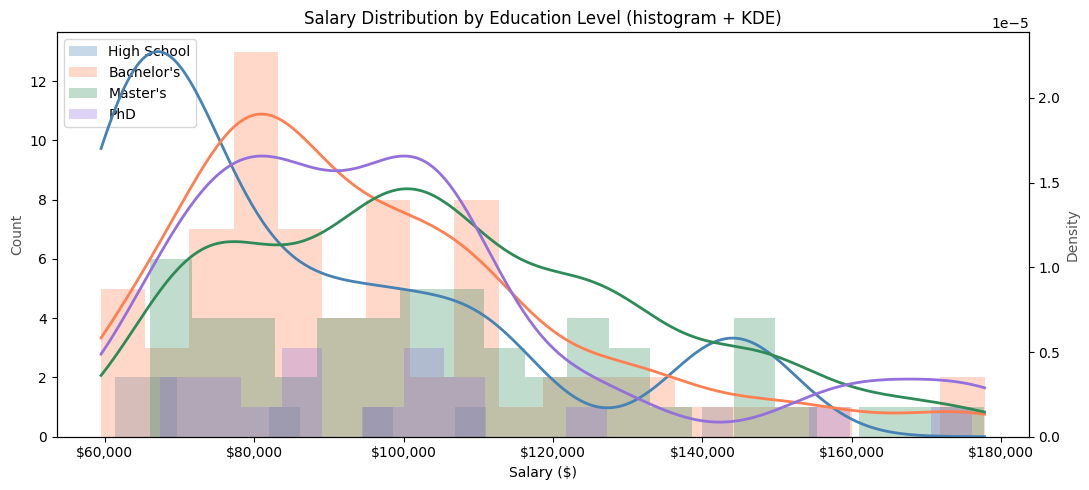

In [8]:
from scipy.stats import gaussian_kde

edu_order = ["High School", "Bachelor's", "Master's", "PhD"]
colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

for edu, color in zip(edu_order, colors):
    subset = df[df['education'] == edu]['salary'].values
    ax1.hist(subset, bins=20, alpha=0.3, color=color, label=edu)
    kde = gaussian_kde(subset, bw_method=0.3)
    x_range = np.linspace(df['salary'].min(), df['salary'].max(), 300)
    ax2.plot(x_range, kde(x_range), color=color, linewidth=2)

ax1.set_xlabel('Salary ($)')
ax1.set_ylabel('Count', color='#555')
ax2.set_ylabel('Density', color='#555')
ax2.set_ylim(bottom=0)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.set_title('Salary Distribution by Education Level (histogram + KDE)')
ax1.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [9]:
edu_order = ["High School", "Bachelor's", "Master's", "PhD"]

summary = (
    df.groupby('education')['salary']
    .agg(count='count', mean='mean', median='median', std='std', min='min', max='max')
    .reindex(edu_order)
    .round(2)
)
summary.columns = ['Count', 'Mean', 'Median', 'Std Dev', 'Min', 'Max']
summary.style.format({'Mean': '${:,.0f}', 'Median': '${:,.0f}',
                       'Std Dev': '${:,.0f}', 'Min': '${:,.0f}', 'Max': '${:,.0f}'})

,Count,Mean,Median,Std Dev,Min,Max
education,,,,,,
High School,8,"$87,111","$75,899","$28,563","$61,391","$144,054"
Bachelor's,70,"$96,379","$89,658","$26,099","$59,524","$177,757"
Master's,55,"$106,503","$102,460","$27,860","$66,136","$177,637"
PhD,17,"$100,070","$98,496","$30,000","$67,423","$176,046"


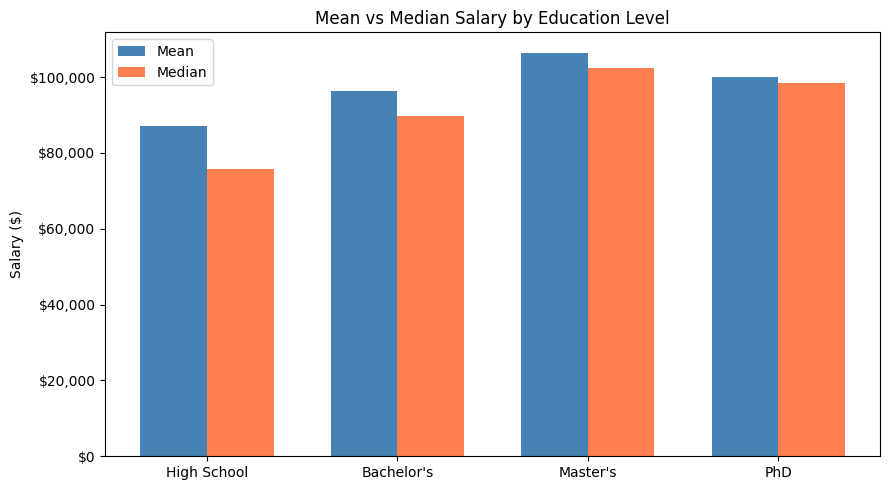

In [10]:
x = np.arange(len(edu_order))
width = 0.35

means   = [summary.loc[e, 'Mean']   for e in edu_order]
medians = [summary.loc[e, 'Median'] for e in edu_order]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, means,   width, label='Mean',   color='steelblue')
ax.bar(x + width/2, medians, width, label='Median', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(edu_order)
ax.set_ylabel('Salary ($)')
ax.set_title('Mean vs Median Salary by Education Level')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()